# 02 — Análise Exploratória (EDA)

Exploração da série de consumo sintética: volume total, distribuição por
categoria/centro de trabalho, produtos de maior/menor giro, semanas zero
e sinais de sazonalidade/tendência.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt

from config import DATA_PROCESSED_DIR, DATA_RAW_DIR

weekly = pd.read_csv(DATA_PROCESSED_DIR / "weekly_series.csv")
products = pd.read_csv(DATA_RAW_DIR / "products.csv")

weekly.head()

,product_id,week_id,units_consumed,week_start,week_end,year,week_of_year,category,criticality
0,MAT001,1,12,2024-09-16,2024-09-22,2024,38,ABRASIVOS,HIGH
1,MAT001,2,7,2024-09-23,2024-09-29,2024,39,ABRASIVOS,HIGH
2,MAT001,3,16,2024-09-30,2024-10-06,2024,40,ABRASIVOS,HIGH
3,MAT001,4,0,2024-10-07,2024-10-13,2024,41,ABRASIVOS,HIGH
4,MAT001,5,0,2024-10-14,2024-10-20,2024,42,ABRASIVOS,HIGH


## Consumo total semanal

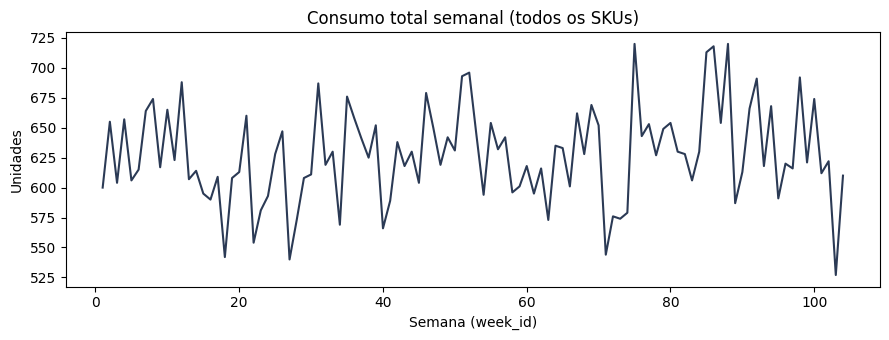

Consumo médio semanal (todos os SKUs): 627.3 unidades
Desvio-padrão semanal: 40.1 unidades


In [2]:
total_weekly = weekly.groupby("week_id")["units_consumed"].sum()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(total_weekly.index, total_weekly.values, color="#2b3a55")
ax.set_title("Consumo total semanal (todos os SKUs)")
ax.set_xlabel("Semana (week_id)")
ax.set_ylabel("Unidades")
plt.tight_layout()
plt.show()

print(f"Consumo médio semanal (todos os SKUs): {total_weekly.mean():.1f} unidades")
print(f"Desvio-padrão semanal: {total_weekly.std():.1f} unidades")

## Consumo por categoria

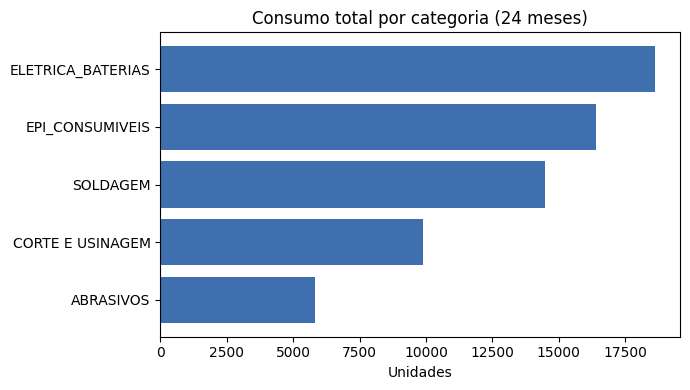

category
ELETRICA_BATERIAS    18636
EPI_CONSUMIVEIS      16393
SOLDAGEM             14485
CORTE E USINAGEM      9892
ABRASIVOS             5838
Name: units_consumed, dtype: int64

In [3]:
by_category = weekly.groupby("category")["units_consumed"].sum().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(by_category.index, by_category.values, color="#3f6fae")
ax.set_title("Consumo total por categoria (24 meses)")
ax.set_xlabel("Unidades")
plt.tight_layout()
plt.show()

by_category.sort_values(ascending=False)

## Produtos de maior e menor giro

In [4]:
by_product = weekly.groupby("product_id")["units_consumed"].sum().sort_values(ascending=False)
top5 = by_product.head(5)
bottom5 = by_product.tail(5)

print("Top 5 maior giro:")
print(top5.to_string())
print("\nTop 5 menor giro:")
print(bottom5.to_string())

Top 5 maior giro:
product_id
MAT011    6983
MAT025    6745
MAT020    5731
MAT022    5181
MAT024    5126

Top 5 menor giro:
product_id
MAT018    399
MAT012    367
MAT003    363
MAT014    344
MAT007    202


## Semanas com consumo zero (intermitência)

**FATO OBSERVADO** (calculado diretamente dos dados, não é suposição):

In [5]:
pct_zero_global = 100 * (weekly["units_consumed"] == 0).mean()
print(f"% de combinações produto-semana com consumo zero: {pct_zero_global:.1f}%")

zero_weeks_by_product = weekly.groupby("product_id").apply(
    lambda g: (g["units_consumed"] == 0).mean() * 100
).sort_values(ascending=False)

print("\nTop 5 produtos com mais semanas zero (%):")
print(zero_weeks_by_product.head(5).round(1).to_string())

% de combinações produto-semana com consumo zero: 11.6%

Top 5 produtos com mais semanas zero (%):
product_id
MAT012    69.2
MAT007    67.3
MAT001    61.5
MAT014    51.0
MAT006    48.1


**HIPÓTESE** (não comprovada diretamente pelos dados acima, mas coerente
com o perfil atribuído no gerador): os produtos com mais semanas zero
tendem a ser os classificados como perfil "INTERMITENTE" internamente em
`generate_data.py` — precisaria cruzar com o perfil de cada produto para
confirmar estatisticamente, o que não foi feito aqui.

## Variabilidade por produto (candidatos a mais difíceis de prever)

In [6]:
cv_by_product = weekly.groupby("product_id")["units_consumed"].agg(["mean", "std"])
cv_by_product["cv"] = cv_by_product["std"] / cv_by_product["mean"].replace(0, pd.NA)
cv_by_product.sort_values("cv", ascending=False).head(10)

,mean,std,cv
product_id,,,
MAT012,3.528846,6.038641,1.711222
MAT007,1.942308,3.133988,1.613538
MAT001,4.884615,7.198041,1.473615
MAT014,3.307692,3.985598,1.204948
MAT006,5.932692,6.611647,1.114443
MAT023,7.798077,8.294787,1.063696
MAT008,8.461538,3.864006,0.456655
MAT026,7.173077,3.076508,0.428897
MAT019,7.490385,3.049734,0.407153


## Conclusão

- Existe variação real de volume entre categorias (não é ruído uniforme).
- Uma fração relevante das combinações produto-semana tem consumo zero —
  por isso a série semanal preserva essas linhas em vez de descartá-las.
- Produtos com alto coeficiente de variação (desvio-padrão / média) são os
  candidatos naturais a maior erro de previsão — confirmado depois em
  `03_model_analysis.ipynb` e no dashboard (página "Qualidade do Modelo").